In [7]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:
import warnings
warnings.filterwarnings("ignore")

## 1. Loading Data

In [3]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               

In [17]:
tesla_data = pd.DataFrame(df)
tesla_data

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_enc,Model_enc,Source_enc,Quarter,Efficiency_km_kWh,Price_per_km
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,1,2,1,2,5.866667,131.923679
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0,3,2,1,5.840000,142.022032
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,3,3,1,1,5.853659,245.598583
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,3,1,2,1,5.933333,125.414199
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2,4,0,4,5.508333,173.747020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273,2,4,2,4,5.991667,158.235188
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833,2,2,2,3,5.939024,168.151273
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709,0,2,0,3,5.800000,167.481690
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754,0,0,1,2,5.966667,195.504385


## 2. Preprocessing

In [4]:
print("\nNull values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Null values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Duplicates: 0


## 3. EDA (Exploratory Data analysis)

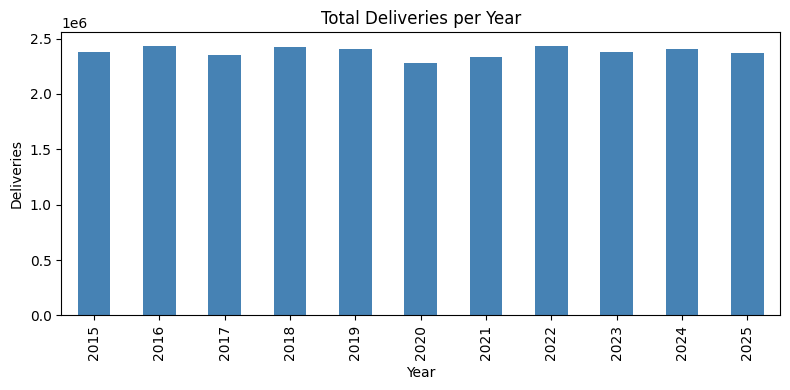

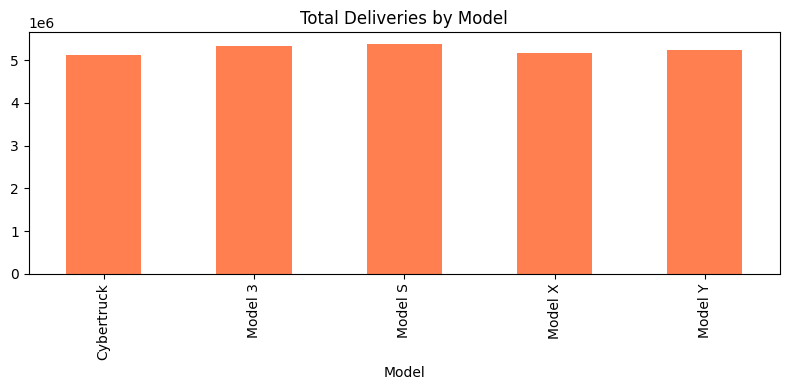

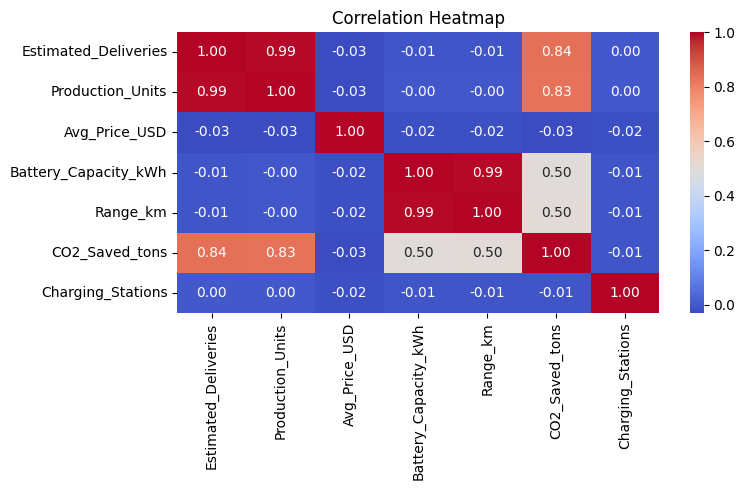

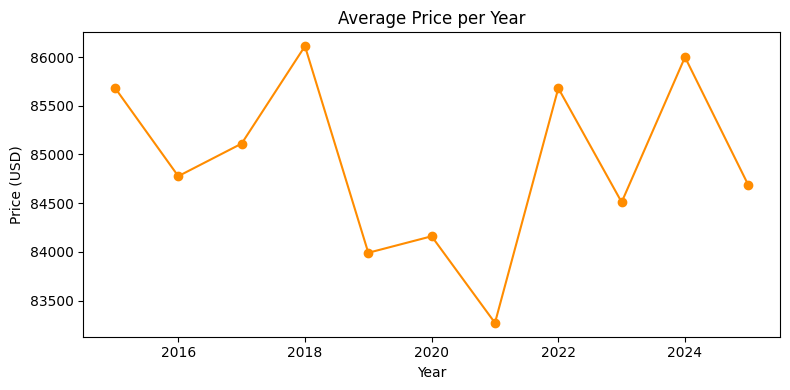

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Deliveries per year
df.groupby("Year")["Estimated_Deliveries"].sum().plot(kind="bar", color="steelblue", figsize=(8,4))
plt.title("Total Deliveries per Year")
plt.ylabel("Deliveries")
plt.tight_layout()
plt.savefig("eda_yearly.png")
plt.show()

# Plot 2: Deliveries by Model
df.groupby("Model")["Estimated_Deliveries"].sum().plot(kind="bar", color="coral", figsize=(8,4))
plt.title("Total Deliveries by Model")
plt.tight_layout()
plt.savefig("eda_model.png")
plt.show()

# Plot 3: Correlation heatmap
plt.figure(figsize=(8,5))
num_cols = ["Estimated_Deliveries","Production_Units","Avg_Price_USD",
            "Battery_Capacity_kWh","Range_km","CO2_Saved_tons","Charging_Stations"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_corr.png")
plt.show()

# Plot 4: Average price over years
df.groupby("Year")["Avg_Price_USD"].mean().plot(marker="o", figsize=(8,4), color="darkorange")
plt.title("Average Price per Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("eda_price.png")
plt.show()

## 4. Feature Engineering

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Region_enc"]  = le.fit_transform(df["Region"])
df["Model_enc"]   = le.fit_transform(df["Model"])
df["Source_enc"]  = le.fit_transform(df["Source_Type"])

df["Quarter"]           = ((df["Month"] - 1) // 3) + 1
df["Efficiency_km_kWh"] = df["Range_km"] / df["Battery_Capacity_kWh"]
df["Price_per_km"]      = df["Avg_Price_USD"] / df["Range_km"]

print("\nFeatures after engineering:", df.columns.tolist())


Features after engineering: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Region_enc', 'Model_enc', 'Source_enc', 'Quarter', 'Efficiency_km_kWh', 'Price_per_km']


## 5. Regression modelling

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ["Year","Month","Quarter","Region_enc","Model_enc","Source_enc",
            "Avg_Price_USD","Battery_Capacity_kWh","Range_km",
            "Production_Units","Charging_Stations","Efficiency_km_kWh","Price_per_km"]

X = df[features]
y = df["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

def evaluate(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    print(f"\n{name}")
    print(f"  MAE  : {mean_absolute_error(yte, pred):.2f}")
    print(f"  RMSE : {np.sqrt(mean_squared_error(yte, pred)):.2f}")
    print(f"  R2   : {r2_score(yte, pred):.4f}")
    return model, pred

lr_model, lr_pred = evaluate("Linear Regression", LinearRegression(), X_train_sc, X_test_sc, y_train, y_test)
rf_model, rf_pred = evaluate("Random Forest", RandomForestRegressor(random_state=42), X_train, X_test, y_train, y_test)
gb_model, gb_pred = evaluate("Gradient Boosting", GradientBoostingRegressor(random_state=42), X_train, X_test, y_train, y_test)


Linear Regression
  MAE  : 340.32
  RMSE : 418.04
  R2   : 0.9883

Random Forest
  MAE  : 364.06
  RMSE : 458.32
  R2   : 0.9859

Gradient Boosting
  MAE  : 357.82
  RMSE : 442.36
  R2   : 0.9869


## 6. Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

print("\n--- Hyperparameter Tuning (Random Forest) ---")
param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [None, 10],
    "max_features": ["sqrt", "log2"]
}
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=3, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
best = grid.best_estimator_
best_pred = best.predict(X_test)
print("Best params:", grid.best_params_)
print(f"Tuned RF R2: {r2_score(y_test, best_pred):.4f}")


--- Hyperparameter Tuning (Random Forest) ---
Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Tuned RF R2: 0.9538


## 7. Actual vs Predicted plot

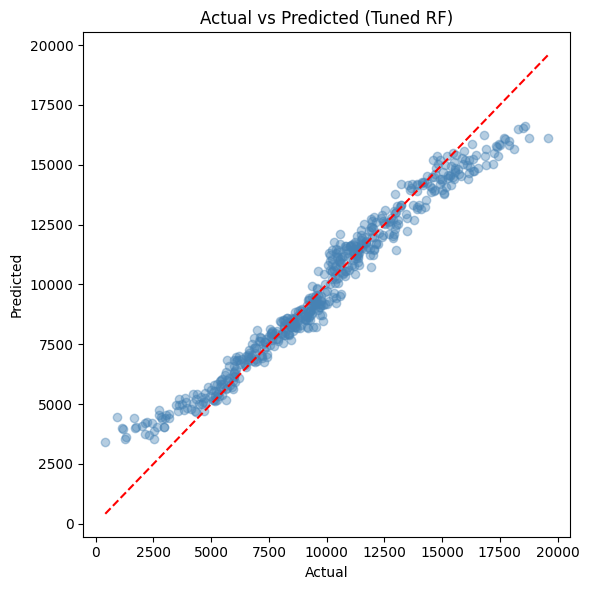

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.4, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Tuned RF)")
plt.tight_layout()
plt.savefig("actual_vs_pred.png")
plt.show()

## 8. Feature Importance

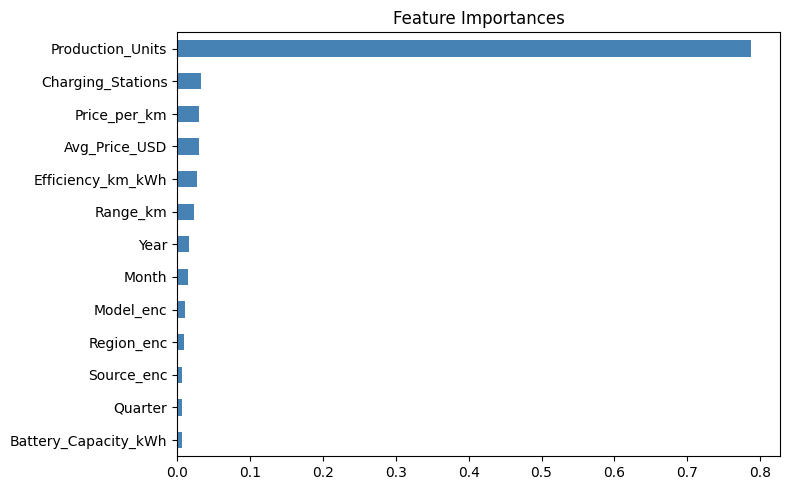

In [13]:
fi = pd.Series(best.feature_importances_, index=features).sort_values()
fi.plot(kind="barh", figsize=(8,5), color="steelblue")
plt.title("Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

## 9. Time Series Forcasting


Time Series R2: -0.6365


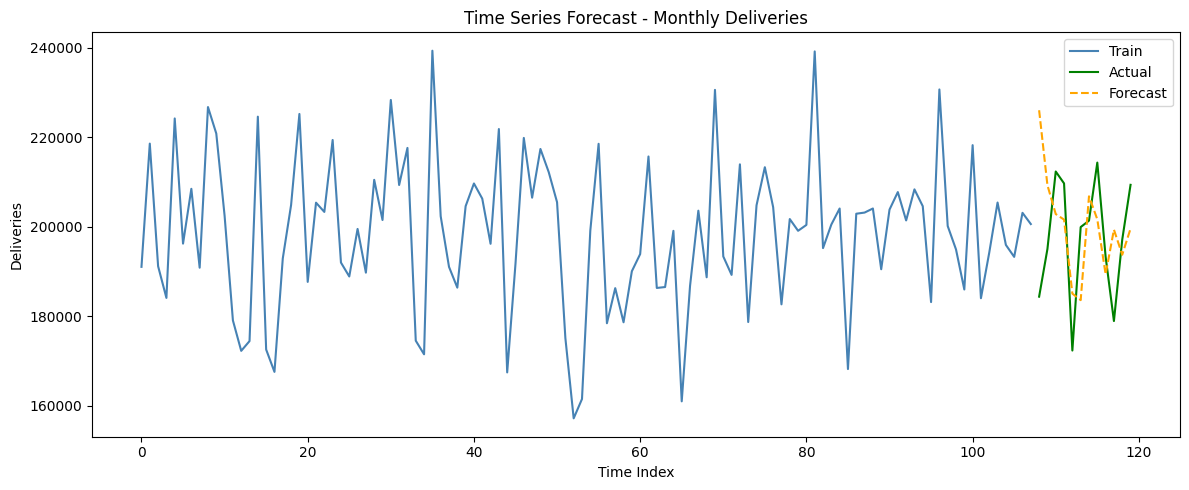

In [15]:
ts = df.groupby(["Year","Month"])["Estimated_Deliveries"].sum().reset_index()
ts = ts.sort_values(["Year","Month"]).reset_index(drop=True)

ts["lag_1"]          = ts["Estimated_Deliveries"].shift(1)
ts["lag_2"]          = ts["Estimated_Deliveries"].shift(2)
ts["lag_3"]          = ts["Estimated_Deliveries"].shift(3)
ts["lag_12"]         = ts["Estimated_Deliveries"].shift(12)
ts["rolling_mean_3"] = ts["Estimated_Deliveries"].shift(1).rolling(3).mean()
ts["trend"]          = np.arange(len(ts))
ts.dropna(inplace=True)

ts_features = ["lag_1","lag_2","lag_3","lag_12","rolling_mean_3","Month","trend"]
X_ts = ts[ts_features]
y_ts = ts["Estimated_Deliveries"]

split = len(ts) - 12
X_ts_tr, X_ts_te = X_ts.iloc[:split], X_ts.iloc[split:]
y_ts_tr, y_ts_te = y_ts.iloc[:split], y_ts.iloc[split:]

ts_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
ts_model.fit(X_ts_tr, y_ts_tr)
ts_pred = ts_model.predict(X_ts_te)

print(f"\nTime Series R2: {r2_score(y_ts_te, ts_pred):.4f}")

plt.figure(figsize=(12,5))
plt.plot(range(split), y_ts_tr.values, label="Train", color="steelblue")
plt.plot(range(split, len(ts)), y_ts_te.values, label="Actual", color="green")
plt.plot(range(split, len(ts)), ts_pred, label="Forecast", color="orange", linestyle="--")
plt.title("Time Series Forecast - Monthly Deliveries")
plt.xlabel("Time Index"); plt.ylabel("Deliveries")
plt.legend()
plt.tight_layout()
plt.savefig("ts_forecast.png")
plt.show()